In [1]:
# preview_csv.py
import csv
from pathlib import Path

def preview_csv(path: str, n: int = 10):
    path = Path(path)

    with path.open("r", newline="", encoding="utf-8") as f:
        reader = csv.reader(f)

        header = next(reader)
        rows = []

        for i, row in enumerate(reader):
            rows.append(row)
            if i + 1 >= n:
                break

    print("\n=== Header ===")
    print(header)

    print(f"\n=== First {n} rows ===")
    for r in rows:
        print(r)


if __name__ == "__main__":
    preview_csv("raw_data/hosp/d_labitems.csv", 10)



=== Header ===
['itemid', 'label', 'fluid', 'category']

=== First 10 rows ===
['50801', 'Alveolar-arterial Gradient', 'Blood', 'Blood Gas']
['50802', 'Base Excess', 'Blood', 'Blood Gas']
['50803', 'Calculated Bicarbonate, Whole Blood', 'Blood', 'Blood Gas']
['50804', 'Calculated Total CO2', 'Blood', 'Blood Gas']
['50805', 'Carboxyhemoglobin', 'Blood', 'Blood Gas']
['50806', 'Chloride, Whole Blood', 'Blood', 'Blood Gas']
['50808', 'Free Calcium', 'Blood', 'Blood Gas']
['50809', 'Glucose', 'Blood', 'Blood Gas']
['50810', 'Hematocrit, Calculated', 'Blood', 'Blood Gas']
['50811', 'Hemoglobin', 'Blood', 'Blood Gas']


In [3]:
import json
from pathlib import Path
input_token, output_token, total_token = 0, 0, 0
with open(Path("log/final_report_agent_context_run.json"), "r", encoding="utf-8") as f:
    logs = json.load(f)
    for p in logs.values():
        input_token += p["token_usage"]["chat"]["prompt_tokens"]
        output_token += p["token_usage"]["chat"]["completion_tokens"]
        total_token += p["token_usage"]["chat"]["total_tokens"]
    print(len(logs))
    print(f"Input tokens: {input_token/1e6}M, Output tokens: {output_token/1e6}M, Total tokens: {total_token/1e6}M")
    

354
Input tokens: 451.904616M, Output tokens: 11.086101M, Total tokens: 462.990717M


In [7]:
import json
from pathlib import Path
input_token, total_token = 0, 0
with open(Path("log/final_report_vector_store.json"), "r", encoding="utf-8") as f:
    logs = json.load(f)
    for p in logs.values():
        if "token_usage" not in p:
            continue
        input_token += p["token_usage"]["embeddings"]["input_tokens"]
        total_token += p["token_usage"]["embeddings"]["total_tokens"]
    print(len(logs))
    print(f"Input tokens: {input_token/1e6}M, Output tokens: {total_token/1e6}M")

87
Input tokens: 41.909539M, Output tokens: 41.909539M


Found 355 patient question files


Scanning questions: 100%|██████████| 355/355 [00:03<00:00, 98.97it/s] 



===== SUMMARY =====
{
  "num_patients": 355,
  "total_questions": 33860,
  "mean_per_patient": 95.38028169014085,
  "std_per_patient": 54.5215724709897,
  "var_per_patient": 2972.6018647093824,
  "min_per_patient": 10,
  "max_per_patient": 418,
  "type_distribution": {
    "T3-N": 13935,
    "T3-A": 5171,
    "T3-M": 7411,
    "T3-D": 6941,
    "T3-P": 402
  }
}


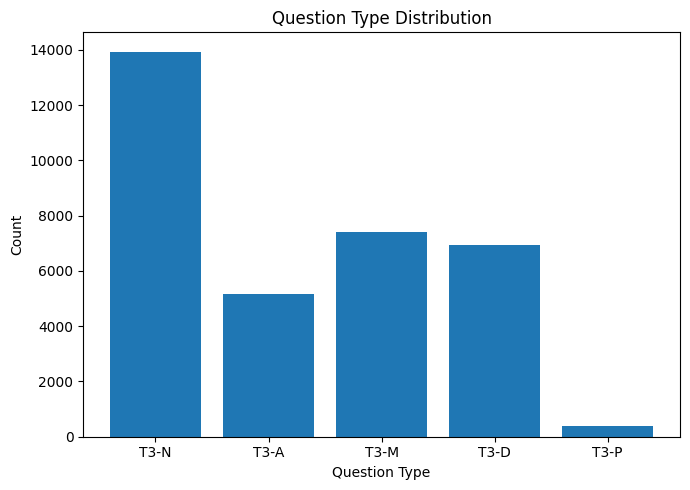

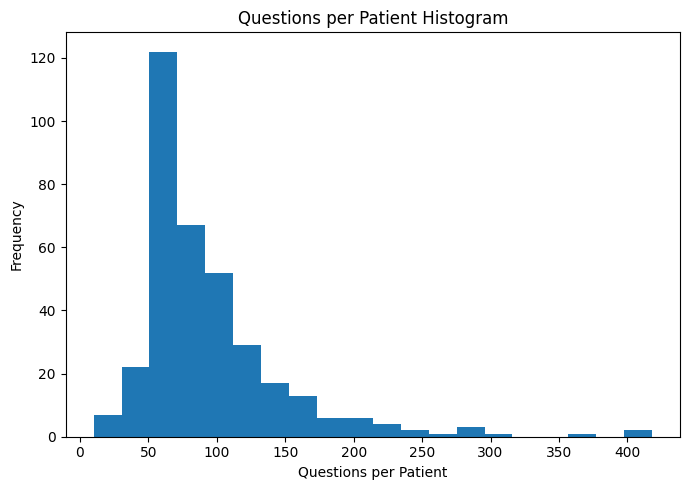


Saved results to log


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
统计：
1) 总问题数
2) 每类问题数
3) 每病人问题数 mean / var / std
4) 可视化：
   - question type bar chart
   - per-patient histogram
"""

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from tqdm import tqdm

# ========= 修改这里 =========
QUESTIONS_DIR = Path("tasks/agentic_decision/questions_generated")
OUT_DIR = Path("log")
# ===========================

OUT_DIR.mkdir(exist_ok=True, parents=True)


def iter_jsonl_files(root: Path):
    return sorted(root.glob("*.jsonl"))


def parse_question_type(obj: dict) -> str:
    """
    兼容多种 schema：
    优先顺序：
      type / qtype / task_type / category
    """
    for k in ["type", "qtype", "task_type", "category"]:
        if k in obj:
            return str(obj[k])
    return "UNKNOWN"


def main():

    files = list(iter_jsonl_files(QUESTIONS_DIR))
    print(f"Found {len(files)} patient question files")

    type_counter = Counter()
    per_patient_counts = []

    total_questions = 0

    for f in tqdm(files, desc="Scanning questions"):
        count_this_patient = 0

        with f.open() as fin:
            for line in fin:
                obj = json.loads(line)

                qtype = parse_question_type(obj)
                type_counter[qtype] += 1

                count_this_patient += 1
                total_questions += 1

        per_patient_counts.append(count_this_patient)

    arr = np.array(per_patient_counts)

    stats = {
        "num_patients": len(files),
        "total_questions": int(total_questions),
        "mean_per_patient": float(arr.mean()),
        "std_per_patient": float(arr.std()),
        "var_per_patient": float(arr.var()),
        "min_per_patient": int(arr.min()),
        "max_per_patient": int(arr.max()),
        "type_distribution": dict(type_counter),
    }

    # ========= print =========
    print("\n===== SUMMARY =====")
    print(json.dumps(stats, indent=2))

    # ========= save json =========
    with (OUT_DIR / "question_stats.json").open("w") as f:
        json.dump(stats, f, indent=2)

    # ========= plot 1: type distribution =========
    types = list(type_counter.keys())
    values = [type_counter[t] for t in types]

    plt.figure(figsize=(7, 5))
    plt.bar(types, values)
    plt.xlabel("Question Type")
    plt.ylabel("Count")
    plt.title("Question Type Distribution")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "question_type_distribution.png")
    plt.show()
    plt.close()

    # ========= plot 2: per patient histogram =========
    plt.figure(figsize=(7, 5))
    plt.hist(arr, bins=20)
    plt.xlabel("Questions per Patient")
    plt.ylabel("Frequency")
    plt.title("Questions per Patient Histogram")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "questions_per_patient_hist.png")
    plt.show()
    plt.close()

    print(f"\nSaved results to {OUT_DIR}")


if __name__ == "__main__":
    main()


In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
统计 LongMedBench event_stream 规模

输入:
  bench_data/patients_sequence/*_sequenced.json

输出:
  log/
    event_stats.json
    events_per_patient_hist.png
    events_per_visit_hist.png
    event_type_distribution.png
"""

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm


# ========= 修改这里 =========
SEQ_DIR = Path("bench_data/patients_sequence")
OUT_DIR = Path("log")
# ===========================

OUT_DIR.mkdir(parents=True, exist_ok=True)


def iter_seq_files(root: Path):
    return sorted(root.glob("*_sequenced.json"))


def main():

    files = list(iter_seq_files(SEQ_DIR))
    print(f"Found {len(files)} sequenced patients")

    per_patient_events = []
    per_visit_events = []
    type_counter = Counter()

    total_events = 0
    total_visits = 0

    for f in tqdm(files, desc="Scanning event streams"):
        events = json.loads(f.read_text())

        total_events += len(events)
        per_patient_events.append(len(events))

        visit_counter = Counter()

        for ev in events:
            et = ev.get("event_type", "UNKNOWN")
            vref = ev.get("visit_ref", "UNK")

            type_counter[et] += 1
            visit_counter[vref] += 1

        for v in visit_counter.values():
            per_visit_events.append(v)

        total_visits += len(visit_counter)

    p_arr = np.array(per_patient_events)
    v_arr = np.array(per_visit_events)

    stats = {
        "num_patients": len(files),
        "total_events": int(total_events),

        "events_per_patient": {
            "mean": float(p_arr.mean()),
            "std": float(p_arr.std()),
            "var": float(p_arr.var()),
            "min": int(p_arr.min()),
            "max": int(p_arr.max()),
        },

        "total_visits": int(total_visits),

        "events_per_visit": {
            "mean": float(v_arr.mean()),
            "std": float(v_arr.std()),
            "var": float(v_arr.var()),
            "min": int(v_arr.min()),
            "max": int(v_arr.max()),
        },

        "event_type_distribution": dict(type_counter),
    }

    print("\n===== EVENT STREAM SUMMARY =====")
    print(json.dumps(stats, indent=2))

    with (OUT_DIR / "event_stats.json").open("w") as f:
        json.dump(stats, f, indent=2)

    # ================= plots =================

    # -------- patient histogram --------
    plt.figure(figsize=(6, 5))
    plt.hist(p_arr, bins=25)
    plt.xlabel("Events per Patient")
    plt.ylabel("Frequency")
    plt.title("Events per Patient Histogram")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "events_per_patient_hist.png")
    plt.close()

    # -------- visit histogram --------
    plt.figure(figsize=(6, 5))
    plt.hist(v_arr, bins=25)
    plt.xlabel("Events per Visit")
    plt.ylabel("Frequency")
    plt.title("Events per Visit Histogram")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "events_per_visit_hist.png")
    plt.close()

    # -------- type bar chart --------
    types = list(type_counter.keys())
    values = [type_counter[t] for t in types]

    plt.figure(figsize=(7, 5))
    plt.bar(types, values)
    plt.xlabel("Event Type")
    plt.ylabel("Count")
    plt.title("Event Type Distribution")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "event_type_distribution.png")
    plt.close()

    print(f"\nSaved all results to {OUT_DIR}")


if __name__ == "__main__":
    main()


Found 355 sequenced patients


Scanning event streams: 100%|██████████| 355/355 [00:02<00:00, 145.10it/s]



===== EVENT STREAM SUMMARY =====
{
  "num_patients": 355,
  "total_events": 328647,
  "events_per_patient": {
    "mean": 925.7661971830986,
    "std": 518.4056533185001,
    "var": 268744.42139258084,
    "min": 94,
    "max": 3285
  },
  "total_visits": 7354,
  "events_per_visit": {
    "mean": 44.68955670383465,
    "std": 69.30260849679078,
    "var": 4802.851544459458,
    "min": 1,
    "max": 1458
  },
  "event_type_distribution": {
    "PATIENT_DEMOGRAPHICS": 355,
    "ADMISSION": 6999,
    "PROCEDURE": 11782,
    "IMAGING": 23432,
    "MEDICATION": 153251,
    "LAB": 80534,
    "MICROBIOLOGY": 33819,
    "DISCHARGE": 6999,
    "VITAL": 11476
  }
}

Saved all results to log
